# HW2 for Hands On Deep Learning -- Fall 2025

## 1. Trainable Parameters Counting
Please manually calculate number of trainable parameters for the following setting

GPT_CONFIG = {
    "vocab_size": 50257    
    "context_length": 1024  
    "emb_dim": 1600
    "n_layers": 48
    "n_heads": 25         
    "drop_rate": 0.1,       
    "bias": False       
}

Also, verify its correctness by calling $\text{sum(p.numel()  for p  in model.parameters()  if p.requires_grad)}$

Token Embeddings = vocab_size x emb_dim = 50257 * 1600 = 80,411,200
Positional Embeddings = context_length x emb_dim = 1024 * 1600 = 1,638,400
Total Embeddings = 80,411,200 + 1,638,400 = 82,049,600

Wq, Wk, Wv ∈ Rd×d = 3d^2
Wo ∈ Rd×d = d^2
W1 ∈ Rd×4d, W2 ∈ R4d×d

Multi-Head Attention params = 3d^2 + d^2 = 4d^2
FFN params = 8d^2
Total per block = 12d^2

For all n_layers = 48 blocks:
n_layers x 12d^2 = 48 * 12 * 1600^2
= 48 * 12 * 2,560,000 = 1,474,560,000

Each Layer norm contributes 2d params = 2(emb_dim) = 2(1600) = 3200

Final Layer Norm = vocab_size x emb_dim = 50257 * 1600 - 80,411,200

Total Parameters = 82,049,600 + 1,474,560,000 + 3200 + 80,411,200 = 1,637,024,000

In [9]:
import torch
import torch.nn as nn
class myselfattention(nn.Module):
    def __init__(self, d_in, d_out,context_length,bias=False):
        super().__init__()
        self.W_value=nn.Linear(d_in,d_out,bias=bias)
        self.W_query=nn.Linear(d_in,d_out,bias=bias)
        self.W_key=nn.Linear(d_in,d_out,bias=bias)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New
    def forward(self, x): 
        _,num_tokens,_=x.shape
        value=self.W_value(x)
        query=self.W_query(x)
        key=self.W_key(x)
        attn_scores=key@query.mT
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)      
        return nn.Softmax(dim=-1)(attn_scores/key.shape[-1]**0.5)@value
myattention=myselfattention(4,4,3)
input=torch.rand(2,3,4)
output=myattention(input)
print(f"output size is: {output.shape}")

class myselfattention_mh(nn.Module):
    def __init__(self, d_in, d_head, d_out,context_length,bias=False):
        super().__init__()
        self.heads=nn.ModuleList([myselfattention(d_in, d_head, context_length) for _ in range(d_out//d_head)])
        self.W_out=nn.Linear(d_out,d_out,bias)
    def forward(self, x): 
        out=torch.cat([self.heads[i](x) for i in range(len(self.heads))], dim=-1)
        return self.W_out(out)
    
class mySilu(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x): 
        ## TODO:
        return x*torch.sigmoid(x)
    
class ffn(nn.Module):
    def __init__(self,dim,dropout=0,bias=False):
        super().__init__()
        ## TODO
        self.net=nn.Sequential(
            nn.Linear(dim,4*dim,bias=bias),
            mySilu(),
            nn.Linear(4*dim,dim,bias=bias),
            nn.Dropout(dropout)
        )
    def forward(self, x): 
        ## TODO
        x = self.net(x)
        return x
    
class myTransformer(nn.Module):
    def __init__(self, heads, dropout, hidden,context_length,bias=False):
        super().__init__()
        ## TODO
        self.ln1=nn.LayerNorm(hidden, elementwise_affine=False)
        self.attn=myselfattention_mh(hidden,hidden//heads,hidden,context_length,bias)
        self.dropout=nn.Dropout(dropout)
        self.ln2=nn.LayerNorm(hidden, elementwise_affine=False)
        self.ffn=ffn(hidden,dropout,bias)
        self.dropout=nn.Dropout(dropout)

    def forward(self, x): 
        ## TODO
        xres1 = x
        x = self.ln1(x)
        x = self.attn(x)
        x = self.dropout(x)
        x = x + xres1

        xres2 = x
        x = self.ln2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + xres2
        return x
    
cfg={
    "layers": 48,
    "heads": 25,
    "dropout": 0.1,
    "context_length": 1024,
    "hidden_dim": 1600,
    "voc_size": 50257
}
class myGPT2(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers=cfg["layers"]
        self.heads=cfg["heads"]
        self.dropout=cfg["dropout"]
        self.context_length=cfg["context_length"]
        self.hidden_dim=cfg["hidden_dim"]
        self.voc_size=cfg["voc_size"]
        self.wte=nn.Embedding(self.voc_size,self.hidden_dim)
        self.wpe=nn.Embedding(self.context_length,self.hidden_dim)
        self.layernorm=nn.LayerNorm(self.hidden_dim)
        self.finalLinear=nn.Linear(self.hidden_dim,self.voc_size,bias=False)
        self.transformerBlocks=nn.ModuleList([myTransformer(self.heads,self.dropout,self.hidden_dim,self.context_length, bias=False) for _ in range(self.layers)])
        self.dropout_layer=nn.Dropout(self.dropout)
    def forward(self, x): 
        batch,length=x.shape
        te=self.wte(x);
        pe=self.wpe(torch.arange(length));
        ## TODO
        x = te+pe
        x = self.dropout_layer(x)
        for block in self.transformerBlocks:
            x = block(x)
        x = self.layernorm(x)
        x = self.finalLinear(x)
        return x
    
x=torch.tensor([[1, 2, 3], [4, 5, 6]])
model=myGPT2(cfg)
model(x).shape

print("Number of parameters: ", count_parameters(model))

output size is: torch.Size([2, 3, 4])
Number of parameters:  1637024000


## 2. Training A model with Different Optimizer Option


Please train GPT2-Small with  [combined_6.txt](https://clemson.instructure.com/courses/268161/files?preview=28185265), where the optimizer candidates are \{SGD, AdamW, Adamax\} (see more details [here](https://docs.pytorch.org/docs/main/optim.html)). Plot the training loss vs. iteration for each of the optimizer in one figure while validation loss vs iteration in another figure.


In [1]:
import torch
import torch.nn as nn
class myselfattention(nn.Module):
    def __init__(self, d_in, d_out,context_length,bias=True):
        super().__init__()
        self.W_value=nn.Linear(d_in,d_out,bias=bias)
        self.W_query=nn.Linear(d_in,d_out,bias=bias)
        self.W_key=nn.Linear(d_in,d_out,bias=bias)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New
    def forward(self, x): 
        _,num_tokens,_=x.shape
        value=self.W_value(x)
        query=self.W_query(x)
        key=self.W_key(x)
        attn_scores=query@key.mT
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)      
        return nn.Softmax(dim=-1)(attn_scores/key.shape[-1]**0.5)@value
myattention=myselfattention(4,4,3)
input=torch.rand(2,3,4)
output=myattention(input)
print(f"output size is: {output.shape}")

output size is: torch.Size([2, 3, 4])


In [2]:
class myselfattention_mh(nn.Module):
    def __init__(self, d_in, d_head, d_out,context_length,bias=True):
        super().__init__()
        self.heads=nn.ModuleList([myselfattention(d_in, d_out//d_head, context_length) for _ in range(d_head)])
        self.W_out=nn.Linear(d_out,d_out,bias)
    def forward(self, x): 
        out=torch.cat([self.heads[i](x) for i in range(len(self.heads))], dim=-1)
        return self.W_out(out)

In [3]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(myselfattention_mh(16,8,16,7))

1088

In [4]:
class mySilu(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x): 
        return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2/torch.pi))*(x+0.044715*x**3)))

In [5]:
class ffn(nn.Module):
    def __init__(self,dim,dropout=0.1,bias=True):
        super().__init__()
        self.W1=nn.Linear(dim,4*dim,bias)
        self.W2=nn.Linear(4*dim,dim,bias)
        self.dropout=nn.Dropout(dropout)
        self.silu=mySilu()
    def forward(self, x): 
        return self.dropout(self.W2(self.silu(self.W1(x))))

In [6]:
class myTransformer(nn.Module):
    def __init__(self, heads, dropout, hidden,context_length,bias=True):
        super().__init__()
        self.myselfattention_mh=myselfattention_mh(hidden,heads,hidden,context_length)#nn.ModuleList([myselfattention(d_in, d_head) for _ in range(d_out//d_head)])
        self.layernorm1=nn.LayerNorm(hidden)
        self.layernorm2=nn.LayerNorm(hidden)
        self.ffn=ffn(hidden,dropout,bias)
        self.dropout=dropout
    def forward(self, x): 
        shortcut1=x;
        x=self.layernorm1(x)
        x=self.myselfattention_mh(x)
        x=nn.Dropout(self.dropout)(x)
        x=x+shortcut1
        shortcut2=x;
        x=self.layernorm2(x)
        x=self.ffn(x)
        x=nn.Dropout(self.dropout)(x)
        x=x+shortcut2
        return x

In [7]:
cfg={
    "layers": 12,
    "heads": 12,
    "dropout": 0.1,
    "context_length": 1024,
    "hidden_dim": 768,
    "voc_size": 50257
}
class myGPT2(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers=cfg["layers"]
        self.heads=cfg["heads"]
        self.dropout=cfg["dropout"]
        self.context_length=cfg["context_length"]
        self.hidden_dim=cfg["hidden_dim"]
        self.voc_size=cfg["voc_size"]
        self.wte=nn.Embedding(self.voc_size,self.hidden_dim)
        self.wpe=nn.Embedding(self.context_length,self.hidden_dim)
        self.layernorm=nn.LayerNorm(self.hidden_dim)
        self.linear=nn.Linear(self.hidden_dim,self.voc_size,bias=False)
        self.transformerBlocks=nn.ModuleList([myTransformer(self.heads,self.dropout,self.hidden_dim,self.context_length) for _ in range(self.layers)])
    def forward(self, x): 
        batch,length=x.shape
        te=self.wte(x);
        pe=self.wpe(torch.arange(length, device=x.device));
        x=te+pe;
        x=nn.Dropout(self.dropout)(x)
        x=nn.Sequential(*self.transformerBlocks)(x)
        x=self.layernorm(x)
        x=self.linear(x)
        return x

In [8]:
x=torch.tensor([[1, 2, 3], [4, 5, 6]])
model=myGPT2(cfg)
model(x).shape

torch.Size([2, 3, 50257])

In [9]:
count_parameters(model)

163037184

In [10]:
input_text1="I study at Clemson"
input_text2="I am a student"
input = [input_text1,input_text2]
import tiktoken

# Load GPT-2 tokenizer
enc = tiktoken.get_encoding("gpt2")

##TODO: how to get the tokens of input
tokens = [enc.encode(text) for text in input]

tokens

model(torch.tensor(tokens)).shape

def generate(model,tokens,max_length):
    for i in range(max_length):
        with torch.no_grad():
            x=model(tokens)
        ##TODO: return the generation with max_length limit
        logits=x[:,-1,:]
        _,idx=torch.max(logits, dim=-1, keepdim=True)
        tokens=torch.cat((tokens, idx), dim=1)
    return tokens
generated=generate(model,torch.tensor(tokens),6)

generated

for i, seq in enumerate(generated.tolist()):
    text = enc.decode(seq)
    print(f"Sequence {i}: {text}")
    
enc.encode(text)

Sequence 0: I study at Clemsonclaimpared loatchingTITamation
Sequence 1: I am a student Cad emot sociology bloggers Judd seizure


[40, 716, 257, 3710, 20517, 4085, 39625, 30357, 49554, 22338]

In [11]:
file_path = "combined_6.txt"
with open(file_path, "r", encoding="utf-8") as file:
    full_text_data = file.read()

fraction = 1/5
subset_len = int(len(full_text_data) * fraction)
text_data = full_text_data[:subset_len]

print(text_data[:99])



“OLD MARY”

By Louis Becke

T. Fisher Unwin, 1901

I

Early one morning, just as the trade wind b


In [12]:
total_characters = len(text_data)
total_tokens = len(enc.encode(text_data,disallowed_special=()))


print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 56667867
Tokens: 16637516


In [13]:
from previous_chapters2 import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=cfg["context_length"],
    stride=cfg["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=cfg["context_length"],
    stride=cfg["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [14]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
    break

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)
    break

Train loader:
torch.Size([2, 1024]) torch.Size([2, 1024])

Validation loader:
torch.Size([2, 1024]) torch.Size([2, 1024])


In [15]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 15042560
Validation tokens: 1592320
All tokens: 16634880


In [16]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch=input_batch.to(device)
    target_batch=target_batch.to(device)
    prediction=model(input_batch)
    return torch.nn.functional.cross_entropy(prediction.flatten(0, 1), target_batch.flatten())
    ##TODO: calculate batch loss

In [17]:
def calc_loss_loader(data_loader, model, device,num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        # num_batches = len(data_loader)
        num_batches = 16
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            total_loss += calc_loss_batch(input_batch, target_batch, model, device).item()
            ##TODO: calculate total_loss which will call function calc_loss_batch defined above
        else:
            break
    return total_loss / num_batches

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) 
torch.manual_seed(123) 
with torch.no_grad(): 
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 11.00387042760849
Validation loss: 10.983667552471161


In [19]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [20]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()  # Calculate loss gradients
            optimizer.step()  # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                if global_step % 1000 == 0:
                    print(f"Ep {epoch+1} (Step {global_step:06d}): "
                          f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.wpe.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

import time
import torch
import matplotlib.pyplot as plt

start_time = time.time()

torch.manual_seed(123)

num_epochs = 1
eval_freq = 5
eval_iter = 5

def steps_from_losses(loss_list, eval_freq):
    return [eval_freq * (i + 1) for i in range(len(loss_list))]

histories = {}

for opt_name in ["SGD", "AdamW", "Adamax"]:
    # fresh model per optimizer (kept your pattern)
    model = myGPT2(cfg)
    model.to(device)

    # minimal optimizer switch
    if opt_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, nesterov=True)
    elif opt_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
    elif opt_name == "Adamax":
        optimizer = torch.optim.Adamax(model.parameters(), lr=0.002, weight_decay=0.0)

    print(f"\n=== Training with {opt_name} ===")
    train_losses, val_losses, tokens_seen = train_model_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=5, eval_iter=5,
        start_context="Every effort moves you", tokenizer=enc
    )

    histories[opt_name] = {
        "train": train_losses,
        "val":   val_losses,
        "steps": steps_from_losses(train_losses, eval_freq),
        "tokens_seen": tokens_seen,
    }


In [21]:
import time
import torch
import matplotlib.pyplot as plt

torch.manual_seed(123)

num_epochs = 1
eval_freq = 100
eval_iter = 1

def steps_from_losses(loss_list, eval_freq):
    return [eval_freq * (i + 1) for i in range(len(loss_list))]

start_time = time.time()

# --- SGD Training ---
model = myGPT2(cfg)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, nesterov=True)

print("\n=== Training with SGD ===")
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=eval_freq, eval_iter=eval_iter,
    start_context="Every effort moves you", tokenizer=enc
)

histories_sgd = {
    "train": train_losses,
    "val":   val_losses,
    "steps": steps_from_losses(train_losses, eval_freq),
    "tokens_seen": tokens_seen,
}

print(f"SGD training completed in {(time.time()-start_time)/60:.2f} min.")


=== Training with SGD ===
Ep 1 (Step 000000): Train loss 10.988, Val loss 11.003
Ep 1 (Step 001000): Train loss 7.636, Val loss 7.323
Ep 1 (Step 002000): Train loss 7.552, Val loss 7.127
Ep 1 (Step 003000): Train loss 4.784, Val loss 6.974
Ep 1 (Step 004000): Train loss 7.535, Val loss 6.891
Ep 1 (Step 005000): Train loss 7.082, Val loss 6.786
Ep 1 (Step 006000): Train loss 6.959, Val loss 6.718
Ep 1 (Step 007000): Train loss 6.764, Val loss 6.641
Every effort moves you,                    “I“”   ” ” “““““” 
SGD training completed in 34.35 min.


In [22]:
torch.manual_seed(123)
start_time = time.time()

# --- AdamW Training ---
model = myGPT2(cfg)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

print("\n=== Training with AdamW ===")
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=eval_freq, eval_iter=eval_iter,
    start_context="Every effort moves you", tokenizer=enc
)

histories_adamw = {
    "train": train_losses,
    "val":   val_losses,
    "steps": steps_from_losses(train_losses, eval_freq),
    "tokens_seen": tokens_seen,
}

print(f"AdamW training completed in {(time.time()-start_time)/60:.2f} min.")


=== Training with AdamW ===
Ep 1 (Step 000000): Train loss 10.147, Val loss 10.220
Ep 1 (Step 001000): Train loss 6.263, Val loss 5.868
Ep 1 (Step 002000): Train loss 5.386, Val loss 5.689
Ep 1 (Step 003000): Train loss 3.678, Val loss 5.575
Ep 1 (Step 004000): Train loss 4.943, Val loss 5.450
Ep 1 (Step 005000): Train loss 5.379, Val loss 5.338
Ep 1 (Step 006000): Train loss 4.848, Val loss 5.334
Ep 1 (Step 007000): Train loss 4.213, Val loss 5.207
Every effort moves you, I and I had been a man, and I had been the same time, and I had been the same time, and I had been the same time, and I had been a man, and I had been a 
AdamW training completed in 35.02 min.


In [23]:
torch.manual_seed(123)
start_time = time.time()

# --- Adamax Training ---
model = myGPT2(cfg)
model.to(device)

optimizer = torch.optim.Adamax(model.parameters(), lr=0.002, weight_decay=0.0)

print("\n=== Training with Adamax ===")
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=eval_freq, eval_iter=eval_iter,
    start_context="Every effort moves you", tokenizer=enc
)

histories_adamax = {
    "train": train_losses,
    "val":   val_losses,
    "steps": steps_from_losses(train_losses, eval_freq),
    "tokens_seen": tokens_seen,
}

print(f"Adamax training completed in {(time.time()-start_time)/60:.2f} min.")


=== Training with Adamax ===
Ep 1 (Step 000000): Train loss 9.924, Val loss 10.015
Ep 1 (Step 001000): Train loss 6.474, Val loss 6.060
Ep 1 (Step 002000): Train loss 5.771, Val loss 5.933
Ep 1 (Step 003000): Train loss 3.954, Val loss 5.866
Ep 1 (Step 004000): Train loss 5.458, Val loss 5.721
Ep 1 (Step 005000): Train loss 5.738, Val loss 5.598
Ep 1 (Step 006000): Train loss 5.303, Val loss 5.609
Ep 1 (Step 007000): Train loss 4.614, Val loss 5.523
Every effort moves you have been, and                                              
Adamax training completed in 34.86 min.


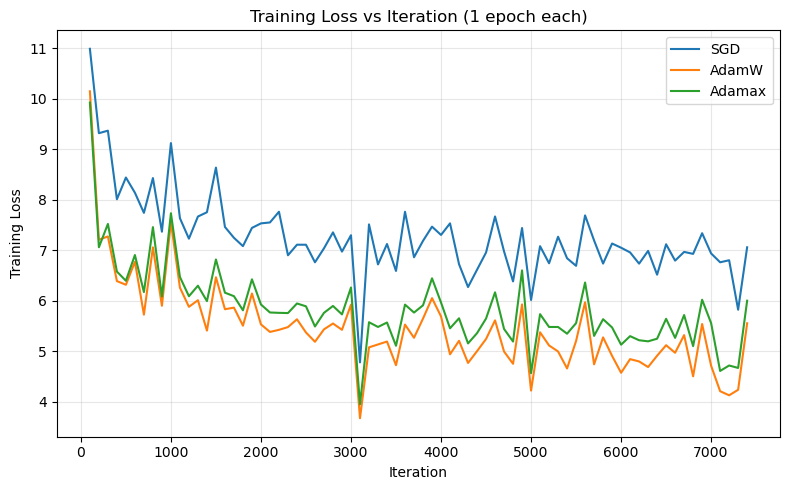

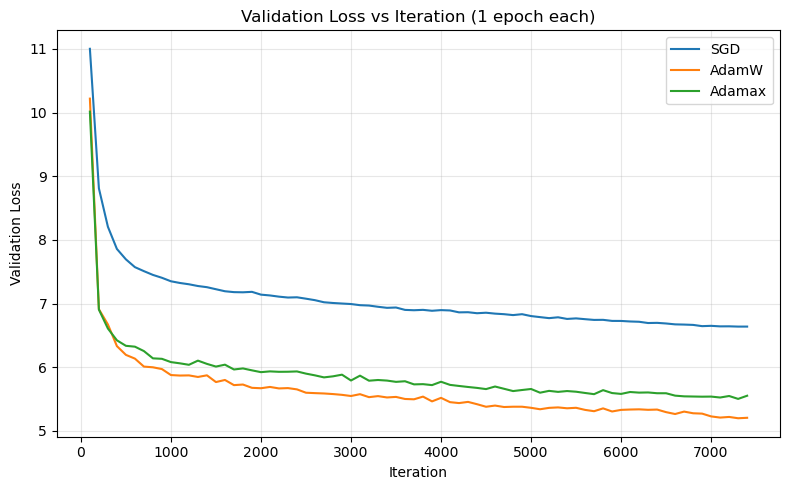

In [24]:
# --- Plot all histories together ---
plt.figure(figsize=(8, 5))
plt.plot(histories_sgd["steps"], histories_sgd["train"], label="SGD")
plt.plot(histories_adamw["steps"], histories_adamw["train"], label="AdamW")
plt.plot(histories_adamax["steps"], histories_adamax["train"], label="Adamax")
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Iteration (1 epoch each)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(histories_sgd["steps"], histories_sgd["val"], label="SGD")
plt.plot(histories_adamw["steps"], histories_adamw["val"], label="AdamW")
plt.plot(histories_adamax["steps"], histories_adamax["val"], label="Adamax")
plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Iteration (1 epoch each)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Softmax in attention

In [Week 7](https://github.com/liukaizhijia/8810_LLM/blob/main/week7_sol.ipynb), we build GPT2 small model. Now please build a same model **without** *softmax*. By loading pretrained weights from OpenAI, we compare the performance (with vs without softmax) on [finetuning classification task](https://clemson.instructure.com/courses/268161/files?preview=28185268). Please plot the accuracy, training loss and validation loss vs. iteration, respectively.



File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
[Step 000000] Train loss: 1.346 | Val loss: 1.419
[Step 000050] Train loss: 0.475 | Val loss: 0.326
[Step 000100] Train loss: 0.121 | Val loss: 0.075
Epoch 1/3 Train acc: 87.75% | Val acc: 81.88%
[Step 000150] Train loss: 0.091 | Val loss: 0.101
[Step 000200] Train loss: 0.079 | Val loss: 0.031
[Step 000250] Train loss: 0.022 | Val loss: 0.042
Epoch 2/3 Train acc: 99.75% | Val acc: 96.64%
[Step 000300] Train loss: 0.014 | Val loss: 0.032
[Step 000350] Train loss: 0.053 | Val loss: 0.335
Epoch 3/3 Train acc: 99.25% | Val acc: 98.66%
File alr

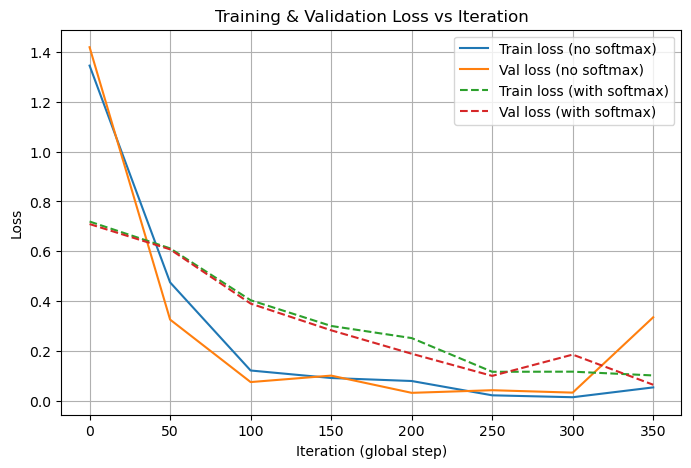

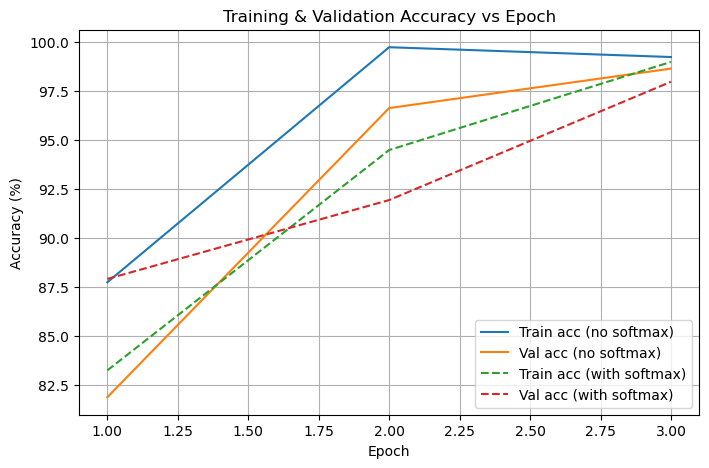

In [2]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import tiktoken

from gpt_download import download_and_load_gpt2
from previous_chapters import (
    GPTModel,
    load_weights_into_gpt,
    SpamDataset,
    calc_accuracy_loader,  
)

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

def build_gpt2_small_base():
    """
    Load GPT-2 small (124M) from OpenAI weights into our GPTModel,
    as in week9_sol.ipynb.
    """
    CHOOSE_MODEL = "gpt2-small (124M)"
    config = BASE_CONFIG.copy()
    config.update(model_configs[CHOOSE_MODEL])

    model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
    settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

    model = GPTModel(config)
    load_weights_into_gpt(model, params)
    return model, config

def build_gpt2_classifier_with_softmax(num_classes=2):
    """
    GPT-2 small classifier that ends with a Linear + Softmax.
    Returns class probabilities.
    """
    base_model, config = build_gpt2_small_base()
    emb_dim = config["emb_dim"]

    # Replace original vocab head with a classifier head: Linear -> Softmax
    base_model.out_head = nn.Sequential(
        nn.Linear(emb_dim, num_classes),
        nn.Softmax(dim=-1)
    )

    return base_model


def build_gpt2_classifier_without_softmax(num_classes=2):
    """
    GPT-2 small classifier that ends with a Linear only.
    Returns raw logits (preferred for nn.CrossEntropyLoss).
    """
    base_model, config = build_gpt2_small_base()
    emb_dim = config["emb_dim"]

    # Replace original vocab head with a classifier head: Linear only
    base_model.out_head = nn.Linear(emb_dim, num_classes)

    return base_model

def calc_loss_batch(input_batch, target_batch, model, device, use_logits=True):
    """
    use_logits=True: model returns raw logits -> use CrossEntropyLoss
    use_logits=False: model returns probabilities -> use NLLLoss(log(probs))
    """
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)

    # model output shape: (batch, seq_len, num_classes)
    outputs = model(input_batch)[:, -1, :]  # last token only

    if use_logits:
        # raw logits: standard and numerically stable
        loss = F.cross_entropy(outputs, target_batch)
    else:
        # outputs are probabilities after Softmax
        probs = outputs
        # Add small epsilon for numerical stability
        log_probs = torch.log(probs + 1e-8)
        loss = F.nll_loss(log_probs, target_batch)

    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None, use_logits=True):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device, use_logits=use_logits)
        total_loss += loss.item()

    return total_loss / num_batches

def train_classifier_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    use_logits=True
):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    steps = []  # global step indices for plotting

    examples_seen, global_step = 0, -1

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device, use_logits=use_logits
            )
            loss.backward()
            optimizer.step()

            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss = calc_loss_loader(
                    train_loader, model, device, num_batches=eval_iter, use_logits=use_logits
                )
                val_loss = calc_loss_loader(
                    val_loader, model, device, num_batches=eval_iter, use_logits=use_logits
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                steps.append(global_step)

                print(
                    f"[Step {global_step:06d}] "
                    f"Train loss: {train_loss:.3f} | Val loss: {val_loss:.3f}"
                )

        # epoch-level accuracy
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        print(
            f"Epoch {epoch+1}/{num_epochs} "
            f"Train acc: {train_accuracy*100:.2f}% | "
            f"Val acc: {val_accuracy*100:.2f}%"
        )

    return {
        "steps": steps,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
}

tokenizer = tiktoken.get_encoding("gpt2")

train_dataset = SpamDataset("train.csv", max_length=None, tokenizer=tokenizer)
val_dataset = SpamDataset("validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)
test_dataset = SpamDataset("test.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)

batch_size = 8
num_workers = 0

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123)

num_epochs = 3      
eval_freq = 50      
eval_iter = 50      

model_no_softmax = build_gpt2_classifier_without_softmax(num_classes=2)
model_no_softmax.to(device)
optimizer_no_softmax = torch.optim.AdamW(model_no_softmax.parameters(), lr=5e-5)

metrics_no_softmax = train_classifier_simple(
    model_no_softmax,
    train_loader,
    val_loader,
    optimizer_no_softmax,
    device,
    num_epochs=num_epochs,
    eval_freq=eval_freq,
    eval_iter=eval_iter,
    use_logits=True,           
)

model_with_softmax = build_gpt2_classifier_with_softmax(num_classes=2)
model_with_softmax.to(device)
optimizer_with_softmax = torch.optim.AdamW(model_with_softmax.parameters(), lr=5e-5)

metrics_with_softmax = train_classifier_simple(
    model_with_softmax,
    train_loader,
    val_loader,
    optimizer_with_softmax,
    device,
    num_epochs=num_epochs,
    eval_freq=eval_freq,
    eval_iter=eval_iter,
    use_logits=False,          
)

print("=== Final test accuracy ===")
test_acc_no_softmax = calc_accuracy_loader(test_loader, model_no_softmax, device)
test_acc_with_softmax = calc_accuracy_loader(test_loader, model_with_softmax, device)

print(f"Without Softmax (logits): {test_acc_no_softmax*100:.2f}%")
print(f"With Softmax:            {test_acc_with_softmax*100:.2f}%")

# Unpack metrics
s_no   = metrics_no_softmax["steps"]
tl_no  = metrics_no_softmax["train_losses"]
vl_no  = metrics_no_softmax["val_losses"]
ta_no  = metrics_no_softmax["train_accs"]
va_no  = metrics_no_softmax["val_accs"]

s_soft = metrics_with_softmax["steps"]
tl_soft = metrics_with_softmax["train_losses"]
vl_soft = metrics_with_softmax["val_losses"]
ta_soft = metrics_with_softmax["train_accs"]
va_soft = metrics_with_softmax["val_accs"]

plt.figure(figsize=(8, 5))
plt.plot(s_no, tl_no, label="Train loss (no softmax)")
plt.plot(s_no, vl_no, label="Val loss (no softmax)")
plt.plot(s_soft, tl_soft, "--", label="Train loss (with softmax)")
plt.plot(s_soft, vl_soft, "--", label="Val loss (with softmax)")
plt.xlabel("Iteration (global step)")
plt.ylabel("Loss")
plt.title("Training & Validation Loss vs Iteration")
plt.legend()
plt.grid(True)
plt.show()

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, [a*100 for a in ta_no], label="Train acc (no softmax)")
plt.plot(epochs, [a*100 for a in va_no], label="Val acc (no softmax)")
plt.plot(epochs, [a*100 for a in ta_soft], "--", label="Train acc (with softmax)")
plt.plot(epochs, [a*100 for a in va_soft], "--", label="Val acc (with softmax)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training & Validation Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()
